## CLASSIFICATION TASKS  : 

## DECISION TREE TASKS AND K-FOLD TASKS AND SUPPORT VECTOR MACHINES BELOW : 

## DECISION TASK : 

## Load Essential Libraries : 

In [78]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn.model_selection import train_test_split

In [79]:
df = pd.read_csv('Copy of titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
# Drop Meaningless information :
df = df.drop(columns = ['PassengerId','Name','SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked'], axis = 'columns')
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


In [81]:
# Data Preprocessing : 

import math
mean_age = df.Age.mean()
mean_age = math.floor(mean_age)
print(mean_age)

29


In [82]:
df['Age'] = df.Age.fillna(mean_age)
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,29.0,23.4500
889,1,1,male,26.0,30.0000


## Label Encode the non numeric feature

In [83]:
LE_sex = LabelEncoder()
df['Sex'] = LE_sex.fit_transform(df['Sex'])
df

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500
...,...,...,...,...,...
886,0,2,1,27.0,13.0000
887,1,1,0,19.0,30.0000
888,0,3,0,29.0,23.4500
889,1,1,1,26.0,30.0000


In [84]:
# Splitting the data :
y = df['Survived']
X = df.drop('Survived', axis = 'columns')
X

,Pclass,Sex,Age,Fare
0,3,1,22.0,7.2500
1,1,0,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500
...,...,...,...,...
886,2,1,27.0,13.0000
887,1,0,19.0,30.0000
888,3,0,29.0,23.4500
889,1,1,26.0,30.0000


## Model Initialization 

In [85]:
model = tree.DecisionTreeClassifier()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4)

## Training the model and checking the score :

In [86]:
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.7563025210084033

## Predicting the result :  

In [87]:
model.predict(X_test)

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [88]:
y_test

129    0
743    0
500    0
275    1
445    1
      ..
35     0
747    1
262    0
50     0
131    0
Name: Survived, Length: 357, dtype: int64

## Exercise for Decision Tree : 

## Try decision tree classifer on the same target column but this time use more feature columns than before.

In [89]:
df = pd.read_csv('Copy of titanic.csv')
df.head()

df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis='columns')
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [90]:
# Data Preprocessing
import math
mean_age = df.Age.mean()
mean_age = math.floor(mean_age)
df['Age'] = df.Age.fillna(mean_age)

In [91]:
# Embarked has a few missing values too — fill with the most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical columns
LE_sex = LabelEncoder()
df['Sex'] = LE_sex.fit_transform(df['Sex'])

LE_embarked = LabelEncoder()
df['Embarked'] = LE_embarked.fit_transform(df['Embarked'])

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2
887,1,1,0,19.0,0,0,30.0000,2
888,0,3,0,29.0,1,2,23.4500,2
889,1,1,1,26.0,0,0,30.0000,0


In [92]:
# Splitting the data
y = df['Survived']
X = df.drop('Survived', axis='columns')
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,2
887,1,0,19.0,0,0,30.0000,2
888,3,0,29.0,1,2,23.4500,2
889,1,1,26.0,0,0,30.0000,0


In [93]:
# Model
model = tree.DecisionTreeClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

In [94]:
print(model.fit(X_train, y_train))
print(model.score(X_test, y_test))

print(model.predict(X_test))

DecisionTreeClassifier()
0.7899159663865546
[0 1 1 0 0 1 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0
 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0
 1 0 0 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0
 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0
 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1 0
 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0
 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1]


## K-FOLD TASK : 

In [95]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

In [96]:
## Load the iris dataset from scikit learn datasets : 
iris =  datasets.load_iris()

In [97]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## Exploring the structure of the iris datasets.

In [98]:
print(dir(iris))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


## 🌳 Cross-Validation with Random Forest Classifier

In this step, we use `cross_val_score()` to evaluate a `RandomForestClassifier` with 35 decision trees (`n_estimators=35`) on the Iris dataset.
Performed `5 fold cross Validation` and used the `R^2` scoring method.
This method splits the data into multiple folds and returns accuracy scores for each fold.


In [99]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),iris.data, iris.target,cv=5, scoring='r2')

In [100]:
print("Fold-wise scores:", rf)
print("Average accuracy:", rf.mean())

Fold-wise scores: [0.95 0.95 0.9  0.95 1.  ]
Average accuracy: 0.95


## 🧪 Cross-Validation with Support Vector Classifier (SVC)

Here, we evaluate an `SVC` (Support Vector Classifier) on the Iris dataset using `cross_val_score()`.

This approach splits the data into multiple folds (by default 5) and trains/tests the model across each fold to assess its generalization performance.

Below, we print the accuracy scores for each fold.


In [101]:
svm = cross_val_score(SVC(), iris.data, iris.target, scoring='r2', cv=10)

In [102]:
print("Fold-wise scores:", svm)
print("Average accuracy:", svm.mean())

Fold-wise scores: [1.  0.9 1.  1.  1.  0.9 0.9 0.9 1.  1. ]
Average accuracy: 0.96


## 📦 Cross-Validation with Logistic Regression

In this section, we evaluate a `LogisticRegression` model on the Iris dataset using `cross_val_score()`.

Since logistic regression may require multiple iterations to converge on some datasets, we specify `max_iter=150` to ensure convergence.

The result is a list of accuracy scores from each fold, providing a more robust measure of model performance.


In [103]:
lr = cross_val_score(LogisticRegression(max_iter=150), iris.data, iris.target, scoring='r2', cv=5)

In [104]:
print("Fold-wise scores:", lr)
print("Average accuracy:", lr.mean())

Fold-wise scores: [0.95 1.   0.9  0.95 1.  ]
Average accuracy: 0.96


## SVC TASK : 

#Support Vector Machine (Supervised Machine Learning)
##Support Vector Machine is a supervised machine learning algorithm used primarily for:

**Classification (e.g., spam detection, image recognition)**

**Regression (SVR – Support Vector Regression)**

In [105]:
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt

In [107]:
# Load the dataset : 
digits = load_digits()

In [108]:
## Explore the Structure of the Digits Dataset
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

## View and Convert the Digits Dataset to a Pandas DataFrame for better visualization

In [110]:
print(digits.data)
df1 = pd.DataFrame(digits.data)
df1

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [111]:
# Or you can do this : 
df = pd.DataFrame(digits.data, columns = digits.feature_names)
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [113]:
# Also append the target col to the dataframe : 
df['Target'] = digits.target
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [114]:
# Import essential libraries : 
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [115]:
# Define feature and target, then perform train_test_split : 
X = df.drop('Target' , axis = 'columns')
y = df['Target']

#X_train, X_test, y_train, y_test = train_test_split(digits.data,digits.target, test_size = 0.2)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3)

## Train and Evaluate the Support Vector Classifier (SVC)

In [116]:
model = SVC()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9777777777777777

In [117]:
result = model.predict(X_test)
result

array([3, 7, 4, 6, 1, 9, 4, 3, 1, 4, 1, 5, 1, 4, 9, 5, 9, 3, 9, 6, 6, 2,
       6, 7, 2, 2, 9, 6, 5, 3, 7, 2, 6, 4, 9, 8, 9, 3, 7, 4, 8, 0, 0, 8,
       1, 7, 5, 1, 9, 7, 0, 0, 8, 9, 2, 9, 6, 5, 2, 0, 9, 7, 5, 2, 6, 9,
       9, 3, 2, 6, 4, 4, 4, 0, 0, 7, 9, 2, 2, 2, 7, 4, 2, 9, 0, 3, 9, 1,
       9, 8, 2, 6, 1, 3, 7, 1, 6, 1, 7, 9, 5, 7, 0, 2, 5, 2, 2, 0, 9, 9,
       2, 9, 1, 9, 7, 4, 1, 2, 7, 8, 7, 8, 0, 0, 2, 3, 2, 2, 0, 2, 4, 9,
       7, 6, 1, 2, 1, 1, 1, 7, 7, 6, 7, 8, 3, 0, 7, 6, 3, 1, 8, 7, 3, 1,
       6, 4, 6, 7, 8, 6, 8, 3, 6, 5, 8, 2, 9, 4, 3, 8, 6, 8, 2, 2, 6, 3,
       9, 8, 9, 4, 3, 8, 3, 7, 2, 9, 2, 9, 3, 9, 2, 4, 5, 9, 1, 0, 2, 9,
       7, 4, 0, 0, 4, 0, 3, 4, 5, 6, 3, 6, 1, 5, 1, 4, 8, 4, 3, 8, 7, 2,
       0, 0, 8, 8, 2, 7, 8, 3, 4, 3, 5, 9, 1, 1, 5, 6, 6, 7, 0, 3, 8, 8,
       4, 7, 4, 1, 4, 9, 4, 3, 5, 2, 3, 5, 9, 5, 2, 8, 5, 4, 4, 0, 8, 4,
       3, 4, 4, 3, 1, 6, 5, 3, 5, 4, 5, 0, 6, 8, 1, 6, 0, 5, 6, 2, 0, 5,
       6, 3, 7, 2, 3, 5, 7, 9, 7, 1, 0, 1, 0, 7, 9,

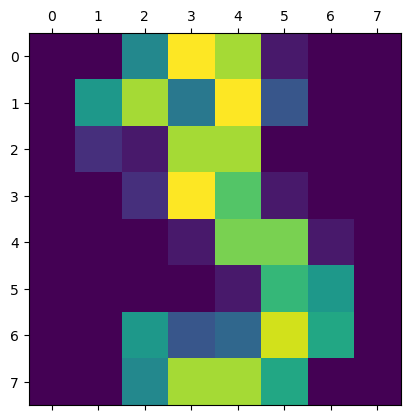

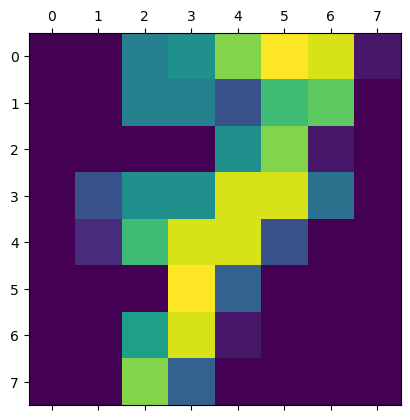

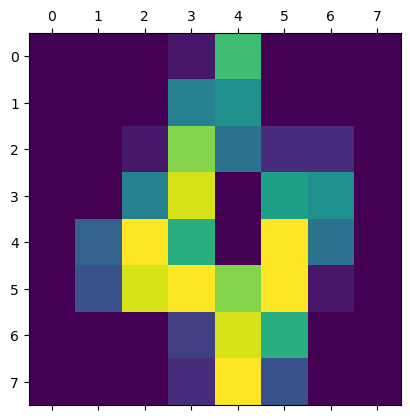

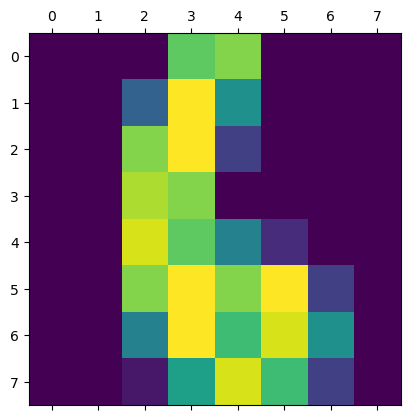

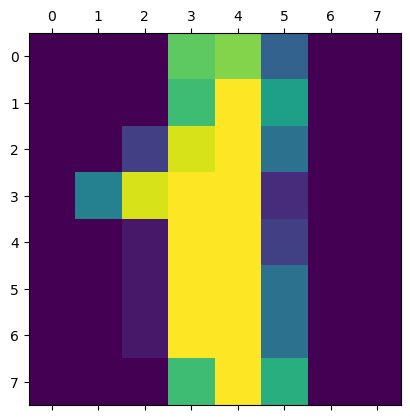

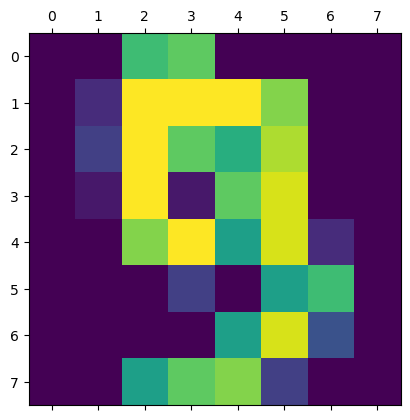

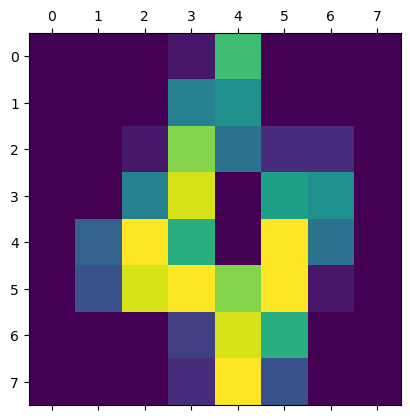

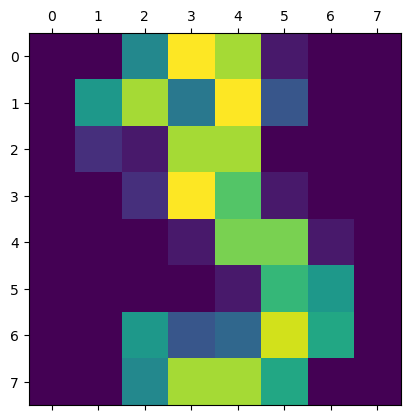

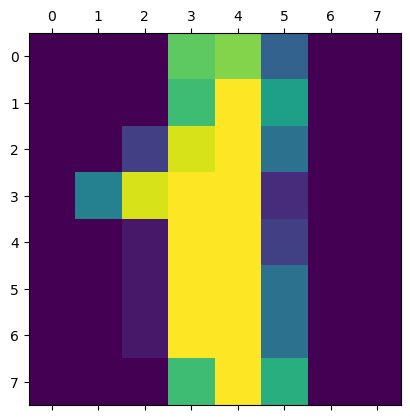

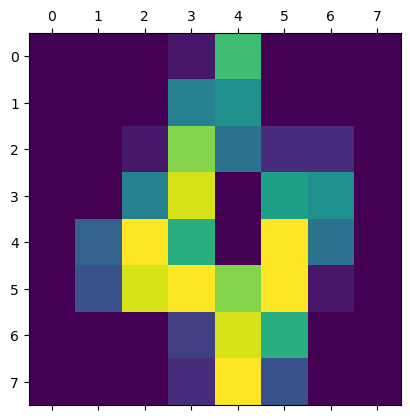

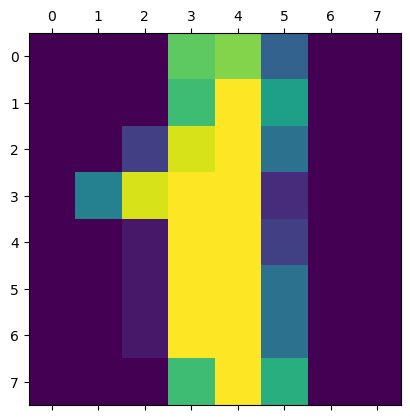

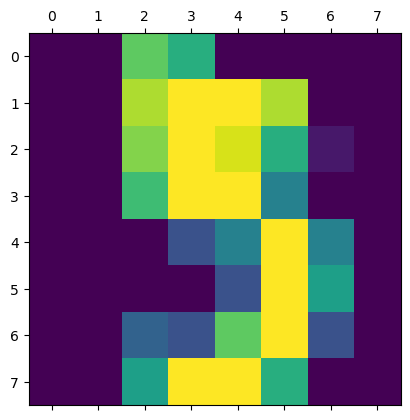

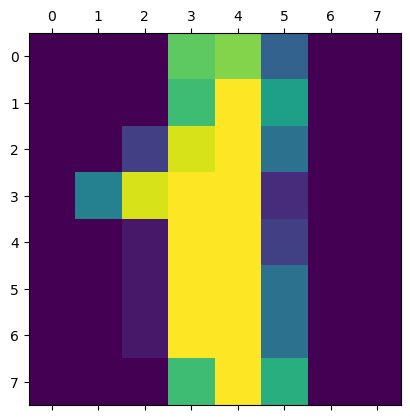

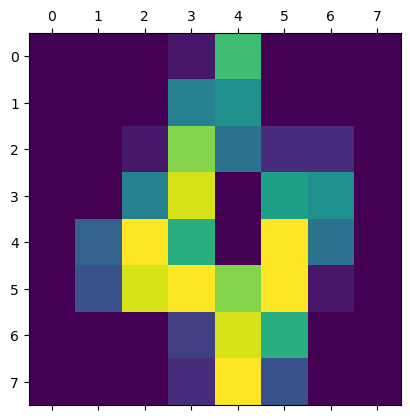

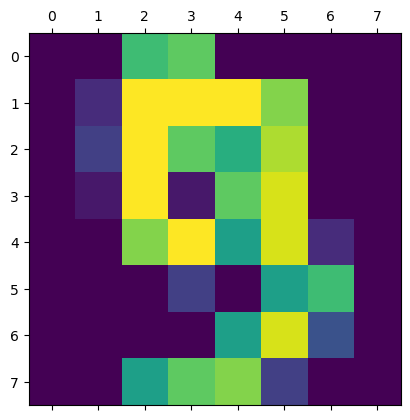

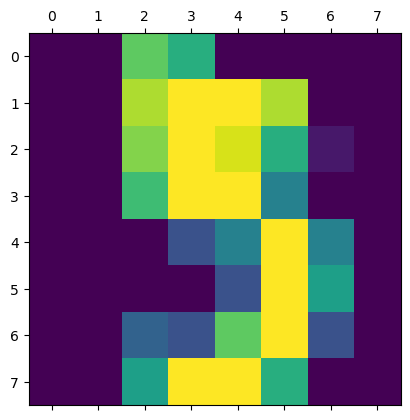

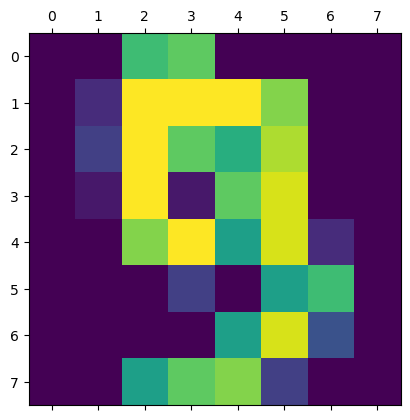

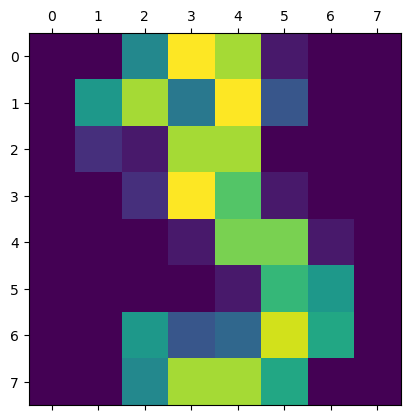

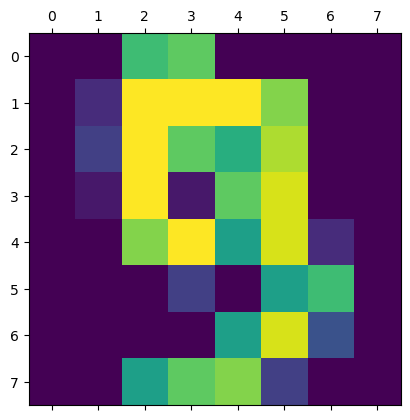

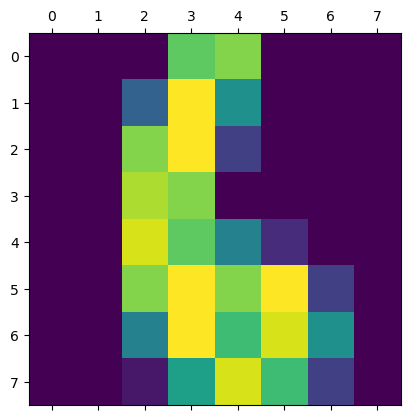

In [119]:
# plot the digit images to visualize them :

for i in range(20):
    plt.matshow(digits.images[result[i]])

## Excellent, now try changing the test size and train the model on Support Vector Classifier to identify how test and train size variation can increase/decrease model accuracy.

Test size: 0.1 -> Train samples: 1617, Test samples: 180, Accuracy: 0.9833
Test size: 0.2 -> Train samples: 1437, Test samples: 360, Accuracy: 0.9861
Test size: 0.3 -> Train samples: 1257, Test samples: 540, Accuracy: 0.9870
Test size: 0.4 -> Train samples: 1078, Test samples: 719, Accuracy: 0.9861
Test size: 0.5 -> Train samples: 898, Test samples: 899, Accuracy: 0.9722


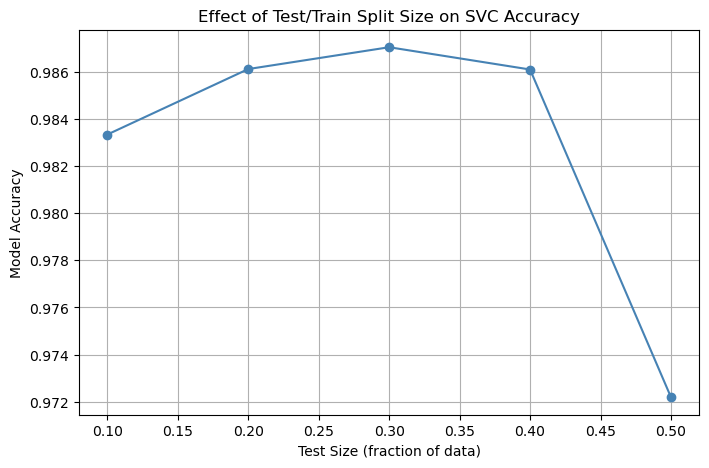

In [120]:
test_sizes = [0.1, 0.2, 0.3, 0.4, 0.5]
accuracies = []

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=42)
    
    model = SVC()
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    
    accuracies.append(score)
    print(f"Test size: {size} -> Train samples: {len(X_train)}, Test samples: {len(X_test)}, Accuracy: {score:.4f}")

# ----- Visualize the relationship -----
plt.figure(figsize=(8,5))
plt.plot(test_sizes, accuracies, marker='o', linestyle='-', color='steelblue')
plt.xlabel('Test Size (fraction of data)')
plt.ylabel('Model Accuracy')
plt.title('Effect of Test/Train Split Size on SVC Accuracy')
plt.grid(True)
plt.show()